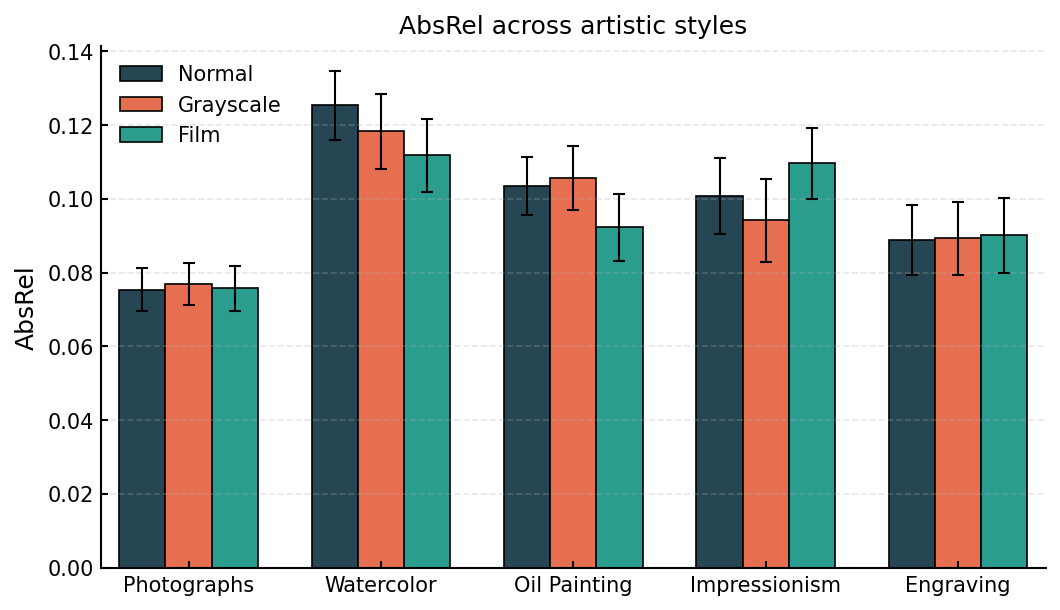

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------------
# Configuration
# --------------------------------------------------
RESULTS_DIR = Path("evaluation_results")
CACHE_CSV_PATH = RESULTS_DIR / "gray_film_results.csv"

METRIC = "AbsRel"
STATISTIC = "MEDIAN"
SAVE_FIGURE = False
OUTPUT_NAME = f"{METRIC}_{STATISTIC}_sem_plot.pdf"

BASELINES = ["photographs", "watercolor", "oil_painting", "impressionism", "engraving"]
DISPLAY_NAMES = {
    "photographs": "Photographs",
    "watercolor": "Watercolor",
    "oil_painting": "Oil Painting",
    "impressionism": "Impressionism",
    "engraving": "Engraving"
}

COLORS = {"Normal": "#264653", "Grayscale": "#E76F51", "Film": "#2A9D8F"}
VARIANTS_LIST = ["Normal", "Grayscale", "Film"]

# --------------------------------------------------
# Matplotlib publication styling
# --------------------------------------------------
# Reverted to matplotlib's default sans-serif font
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# --------------------------------------------------
# Load Data Frame
# --------------------------------------------------
if not CACHE_CSV_PATH.exists():
    raise FileNotFoundError(f"Missing cached summary file at {CACHE_CSV_PATH}. Execute calculation pipeline script first.")

plot_df = pd.read_csv(CACHE_CSV_PATH)

# --------------------------------------------------
# Plot Creation
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(7.2, 4.2))

x = np.arange(len(BASELINES))
width = 0.24

for i, variant in enumerate(VARIANTS_LIST):
    subset = plot_df[plot_df["Variant"] == variant]

    # Reconstruct exact sorting alignment matching base loop settings
    values = [
        subset[subset["Baseline"] == DISPLAY_NAMES[b]]["Value"].values[0]
        for b in BASELINES
    ]
    sems = [
        subset[subset["Baseline"] == DISPLAY_NAMES[b]]["SEM"].values[0]
        for b in BASELINES
    ]

    ax.bar(
        x + (i - 1) * width,
        values,
        width=width,
        yerr=sems,
        capsize=3,
        label=variant,
        color=COLORS[variant],
        linewidth=0.8,
        edgecolor="black",
        error_kw={
            "elinewidth": 1.0,
            "capthick": 1.0
        }
    )

# --------------------------------------------------
# Formatting
# --------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels([DISPLAY_NAMES[b] for b in BASELINES])
ax.set_ylabel(METRIC)
ax.set_title(f"{METRIC} across artistic styles")

ax.legend(frameon=False, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.margins(x=0.02)
plt.tight_layout()

# --------------------------------------------------
# Save figure
# --------------------------------------------------
if SAVE_FIGURE:
    plt.savefig(OUTPUT_NAME, bbox_inches="tight", transparent=True)
    print(f"Saved figure to: {OUTPUT_NAME}")

plt.show()